# Welch t-test Significance — IBEX35 Direction Models

One-sample Welch t-test: are per-fold `balanced_accuracy` scores
significantly greater than random chance (0.5)?

With 66–70 non-overlapping test folds the CLT applies, normality holds,
and Welch's t-test is valid. It makes no equal-variance assumption across models.

**Scope:** `expanding` CV · `discrete` target · horizons **h1** and **h5**  
**Models:** `rf`, `xgb`, `gru`, `lstm`, `cnn_gru`, `cnn_lstm`, `markov`  
**Baseline:** balanced accuracy = 0.5 (random classifier)  
**Test:** one-sample Welch t-test, one-sided (`alternative='greater'`), α = 0.05

## 0. Config

In [7]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from scipy import stats

from config import ARTIFACTS_PATH

ARTIFACTS_DIR = ARTIFACTS_PATH
ALPHA         = 0.05
MODELS        = ['rf', 'xgb', 'gru', 'lstm', 'cnn_gru', 'cnn_lstm', 'markov']
HORIZONS      = [1, 5]

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. Load artifacts & extract per-fold balanced accuracy

In [8]:
# scores[horizon][model] = np.ndarray of per-fold balanced_accuracy values
scores = {h: {} for h in HORIZONS}

for h in HORIZONS:
    print(f'\n--- horizon h{h} ---')
    for model in MODELS:
        path = ARTIFACTS_DIR / f'{model}_h{h}_expanding_discrete.pkl'
        if not path.exists():
            print(f'  WARNING: {path.name} not found — skipping')
            continue
        artifact = joblib.load(path)
        cv_metrics = artifact.get('cv_metrics', [])
        fold_scores = np.array([
            fold['balanced_accuracy']
            for fold in cv_metrics
            if 'balanced_accuracy' in fold
        ])
        if len(fold_scores) == 0:
            print(f'  WARNING: {path.name} has no balanced_accuracy in cv_metrics — skipping')
            continue
        scores[h][model] = fold_scores
        print(f'  {model:12s}  n_folds={len(fold_scores):3d}  '
              f'mean={fold_scores.mean():.4f}  std={fold_scores.std():.4f}')


--- horizon h1 ---
  rf            n_folds= 70  mean=0.5316  std=0.0328
  xgb           n_folds= 70  mean=0.5255  std=0.0328
  gru           n_folds= 70  mean=0.5274  std=0.0306
  lstm          n_folds= 70  mean=0.5234  std=0.0264
  markov        n_folds= 70  mean=0.4992  std=0.0092

--- horizon h5 ---
  rf            n_folds= 66  mean=0.5176  std=0.0464
  xgb           n_folds= 66  mean=0.5070  std=0.0346
  gru           n_folds= 66  mean=0.5158  std=0.0359
  lstm          n_folds= 66  mean=0.5168  std=0.0364
  markov        n_folds= 66  mean=0.5010  std=0.0118


## 2. Welch t-tests

In [9]:
rows = []

for h in HORIZONS:
    for model, fold_scores in scores[h].items():
        n = len(fold_scores)
        mean_ba = float(fold_scores.mean())
        std_ba  = float(fold_scores.std(ddof=1))

        if n < 2:
            rows.append({
                'horizon': h, 'model': model, 'n_folds': n,
                'mean_ba': mean_ba, 'std_ba': std_ba,
                't_stat': np.nan, 'p_value': np.nan, 'significant': False,
            })
            continue

        # One-sample t-test: H0: mean(scores) <= 0.5, H1: mean(scores) > 0.5
        t, p = stats.ttest_1samp(fold_scores, popmean=0.5, alternative='greater')
        rows.append({
            'horizon': h, 'model': model, 'n_folds': n,
            'mean_ba': mean_ba, 'std_ba': std_ba,
            't_stat': t, 'p_value': p,
            'significant': bool(p < ALPHA),
        })

df_results = pd.DataFrame(rows)

## 3. Summary tables

In [10]:
def _style_table(df_h):
    styled = (
        df_h[['model', 'n_folds', 'mean_ba', 'std_ba', 't_stat', 'p_value', 'significant']]
        .sort_values('mean_ba', ascending=False)
        .style
        .format({
            'mean_ba': '{:.4f}',
            'std_ba':  '{:.4f}',
            't_stat':  '{:.3f}',
            'p_value': '{:.4f}',
        })
        .apply(
            lambda row: [
                'background-color: #d4edda' if row['significant'] else ''
                for _ in row
            ],
            axis=1
        )
    )
    return styled

for h in HORIZONS:
    df_h = df_results[df_results['horizon'] == h].copy()
    if df_h.empty:
        print(f'No results for h{h}')
        continue
    print(f'\n=== Horizon h{h} ===')
    display(_style_table(df_h))


=== Horizon h1 ===


,model,n_folds,mean_ba,std_ba,t_stat,p_value,significant
0,rf,70,0.5316,0.0331,7.999,0.0000,True
2,gru,70,0.5274,0.0309,7.432,0.0000,True
1,xgb,70,0.5255,0.0330,6.468,0.0000,True
3,lstm,70,0.5234,0.0266,7.370,0.0000,True
4,markov,70,0.4992,0.0093,-0.681,0.7509,False



=== Horizon h5 ===


,model,n_folds,mean_ba,std_ba,t_stat,p_value,significant
5,rf,66,0.5176,0.0468,3.053,0.0016,True
8,lstm,66,0.5168,0.0367,3.715,0.0002,True
7,gru,66,0.5158,0.0362,3.542,0.0004,True
6,xgb,66,0.5070,0.0349,1.637,0.0532,False
9,markov,66,0.5010,0.0119,0.649,0.2592,False


## 4. Distribution plots

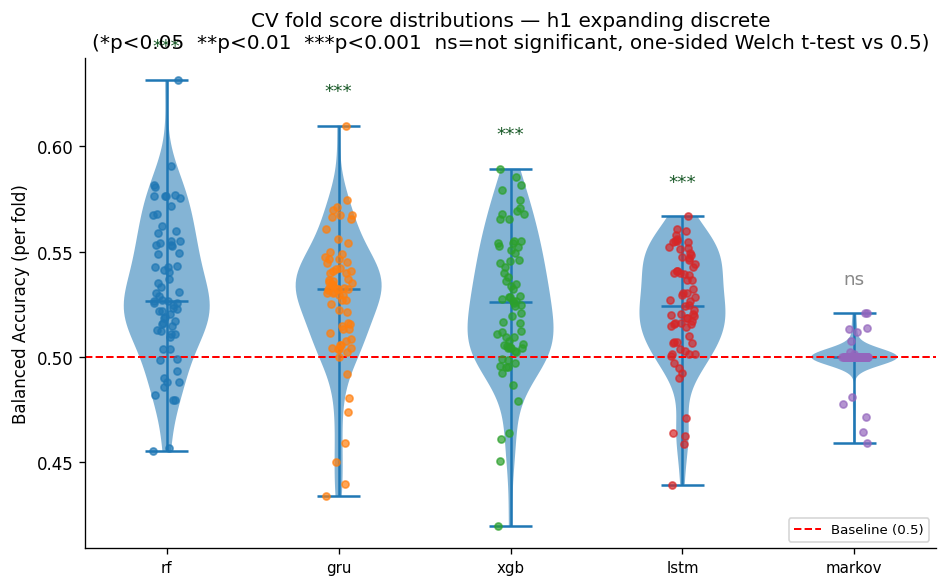

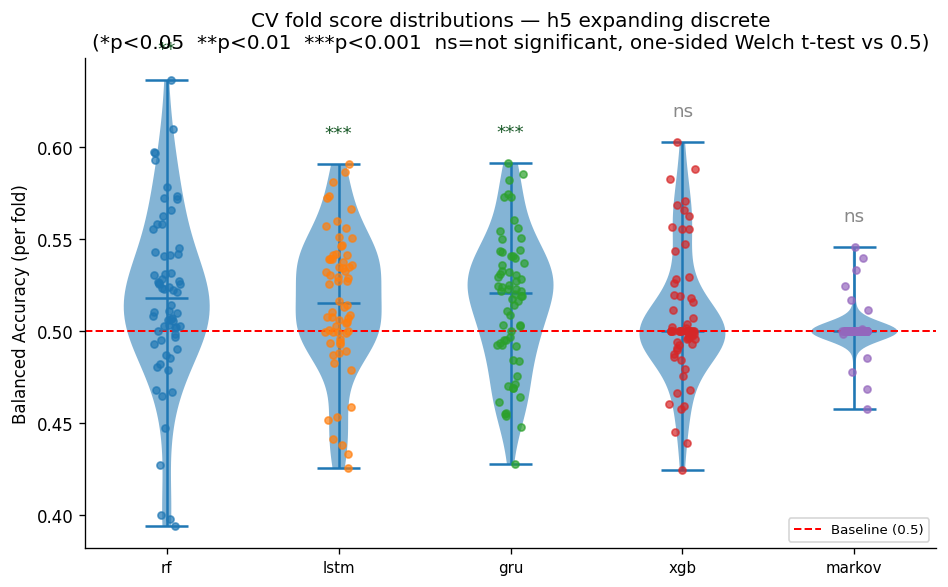

In [11]:
def _star(p):
    if pd.isna(p):  return ''
    if p < 0.001:   return '***'
    if p < 0.01:    return '**'
    if p < 0.05:    return '*'
    return 'ns'

for h in HORIZONS:
    available = [(m, s) for m, s in scores[h].items()]
    if not available:
        continue

    row_map = df_results[df_results['horizon'] == h].set_index('model')
    available_sorted = sorted(
        available,
        key=lambda x: row_map.loc[x[0], 'mean_ba'] if x[0] in row_map.index else 0,
        reverse=True,
    )
    model_names  = [m for m, _ in available_sorted]
    model_scores = [s for _, s in available_sorted]

    fig, ax = plt.subplots(figsize=(max(8, len(model_names) * 1.4), 5))

    parts = ax.violinplot(
        model_scores,
        positions=range(len(model_names)),
        showmedians=True,
        showextrema=True,
    )
    for pc in parts['bodies']:
        pc.set_alpha(0.55)

    for i, s in enumerate(model_scores):
        jitter = np.random.default_rng(i).uniform(-0.08, 0.08, size=len(s))
        ax.scatter(np.full(len(s), i) + jitter, s, s=18, zorder=3, alpha=0.7)

    ax.axhline(0.5, color='red', lw=1.2, ls='--', label='Baseline (0.5)')

    for i, name in enumerate(model_names):
        if name not in row_map.index:
            continue
        p = row_map.loc[name, 'p_value']
        top = max(model_scores[i]) + 0.012
        ax.text(i, top, _star(p), ha='center', va='bottom', fontsize=11,
                color='#155724' if (not pd.isna(p) and p < ALPHA) else '#888')

    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, fontsize=9)
    ax.set_ylabel('Balanced Accuracy (per fold)')
    ax.set_title(f'CV fold score distributions — h{h} expanding discrete\n'
                 f'(*p<0.05  **p<0.01  ***p<0.001  ns=not significant, one-sided Welch t-test vs 0.5)')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

## 5. Interpretation

In [12]:
from IPython.display import Markdown, display

lines = []
for h in HORIZONS:
    lines.append(f'### Horizon h{h}')
    df_h = df_results[df_results['horizon'] == h].sort_values('mean_ba', ascending=False)
    for _, row in df_h.iterrows():
        sig_str = (
            f'**significantly better than chance** ({_star(row["p_value"])}; p={row["p_value"]:.4f})'
            if row['significant']
            else f'*not significantly different from chance* (p={row["p_value"]:.4f})'
            if not pd.isna(row['p_value'])
            else '*test not applicable (insufficient folds)*'
        )
        lines.append(
            f'**{row["model"]} (h{h}):** '
            f'mean BA = {row["mean_ba"]:.4f} ± {row["std_ba"]:.4f}, '
            f't = {row["t_stat"]:.3f}, '
            f'{sig_str} '
            f'(α = {ALPHA}, one-sided Welch t-test, n = {int(row["n_folds"])} folds).'
        )
    lines.append('')

display(Markdown('\n\n'.join(lines)))

### Horizon h1

**rf (h1):** mean BA = 0.5316 ± 0.0331, t = 7.999, **significantly better than chance** (***; p=0.0000) (α = 0.05, one-sided Welch t-test, n = 70 folds).

**gru (h1):** mean BA = 0.5274 ± 0.0309, t = 7.432, **significantly better than chance** (***; p=0.0000) (α = 0.05, one-sided Welch t-test, n = 70 folds).

**xgb (h1):** mean BA = 0.5255 ± 0.0330, t = 6.468, **significantly better than chance** (***; p=0.0000) (α = 0.05, one-sided Welch t-test, n = 70 folds).

**lstm (h1):** mean BA = 0.5234 ± 0.0266, t = 7.370, **significantly better than chance** (***; p=0.0000) (α = 0.05, one-sided Welch t-test, n = 70 folds).

**markov (h1):** mean BA = 0.4992 ± 0.0093, t = -0.681, *not significantly different from chance* (p=0.7509) (α = 0.05, one-sided Welch t-test, n = 70 folds).



### Horizon h5

**rf (h5):** mean BA = 0.5176 ± 0.0468, t = 3.053, **significantly better than chance** (**; p=0.0016) (α = 0.05, one-sided Welch t-test, n = 66 folds).

**lstm (h5):** mean BA = 0.5168 ± 0.0367, t = 3.715, **significantly better than chance** (***; p=0.0002) (α = 0.05, one-sided Welch t-test, n = 66 folds).

**gru (h5):** mean BA = 0.5158 ± 0.0362, t = 3.542, **significantly better than chance** (***; p=0.0004) (α = 0.05, one-sided Welch t-test, n = 66 folds).

**xgb (h5):** mean BA = 0.5070 ± 0.0349, t = 1.637, *not significantly different from chance* (p=0.0532) (α = 0.05, one-sided Welch t-test, n = 66 folds).

**markov (h5):** mean BA = 0.5010 ± 0.0119, t = 0.649, *not significantly different from chance* (p=0.2592) (α = 0.05, one-sided Welch t-test, n = 66 folds).

